In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import sympy as sp

Karakterisztika kiolvasása Abaqus rpt-ból

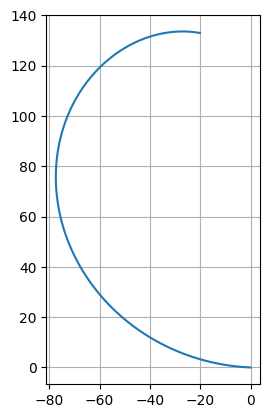

In [3]:
df = pd.read_csv("txtfiles/FEMCHAR.rpt",sep=r"\s+",header=None,engine="python")

arr = df.iloc[1:].astype(float).to_numpy().T

fig, ax1 = plt.subplots()

ax1.grid()
ax1.set_aspect("equal")
ax1.plot(arr[0], arr[1])

plt.show()

Polinom illesztés kimért pozíciókra

-----------------
[ 0. 16. 32. 43. 57. 69. 74.]
[ 0.  1.  7. 13. 27. 39. 61.]
[74. 72. 55.]
[ 61.  83. 113.]
[  0. -19. -33. -45. -56.]
[ 0.  4.  8. 14. 20.]
-----------------
[ 0.01434271 -0.34351258  1.37972875]
------------
------------
[-4.86068111e-01  5.99659443e+01 -1.71477090e+03]
------------
------------
[ 0.00450175 -0.10347867  0.08134529]
------------
------------


C:\Users\Msi\AppData\Local\Temp\ipykernel_29140\2734776751.py:45: OptimizeWarning: Covariance of the parameters could not be estimated
  coeffs2, cov2 = curve_fit(Char_Polynomial2,x2vals,z2vals, maxfev=10000)


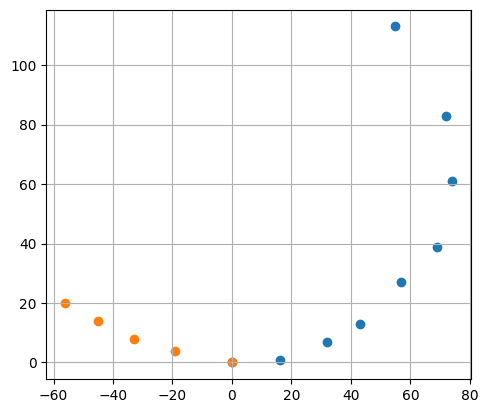

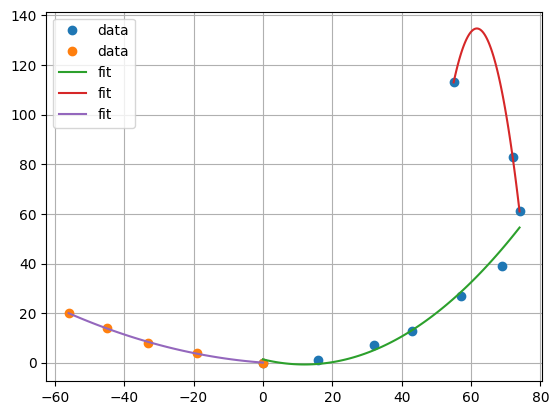

In [4]:
#z = Ax^5+Bx^4+Cx^3+Dx^2+Ex+F - túlnyomás, z'>0
#z = Ax^3+Bx^2+Cx+D - túlnyomás, z'<0
#z = Ax^3+Bx^2+Cx+D - vákuum

x12vals, z12vals = np.loadtxt("txtfiles/MEASCHAR1.txt", delimiter="\t", unpack=True)
x3vals, z3vals = np.loadtxt("txtfiles/MEASCHAR2.txt", delimiter="\t", unpack=True)

x1vals = x12vals[:7]
x2vals = x12vals[6:]
z1vals= z12vals[:7]
z2vals = z12vals[6:]

print("-----------------")
print(x1vals)
print(z1vals)
print(x2vals)
print(z2vals)
print(x3vals)
print(z3vals)
print("-----------------")

fig2, ax2 = plt.subplots()

ax2.grid()
ax2.set_aspect("equal")
ax2.scatter(x12vals, z12vals)
ax2.scatter(x3vals,z3vals)

def Char_Polynomial6(x,A,B,C,D,E,F,G):
    return A*x**6+B*x**5+C*x**4+D*x**3+E*x**2+F*x+G

def Char_Polynomial5(x,A,B,C,D,E,F):
    return A*x**5+B*x**4+C*x**3+D*x**2+E*x+F

def Char_Polynomial4(x,A,B,C,D,E):
    return A*x**4+B*x**3+C*x**2+D*x+E

def Char_Polynomial3(x,A,B,C,D):
    return A*x**3+B*x**2+C*x+D

def Char_Polynomial2(x,A,B,C):
    return A*x**2+B*x+C

coeffs1, cov1 = curve_fit(Char_Polynomial2,x1vals,z1vals, maxfev=10000)
coeffs2, cov2 = curve_fit(Char_Polynomial2,x2vals,z2vals, maxfev=10000)
coeffs3, cov3 = curve_fit(Char_Polynomial2,x3vals,z3vals, maxfev=10000)

print(coeffs1)
print("------------")
#print(cov1)
print("------------")
print(coeffs2)
print("------------")
#print(cov2)
print("------------")
print(coeffs3)
print("------------")
#print(cov3)
print("------------")

xvals_cont_1 = np.linspace(x1vals[0],x1vals[-1],100)
xvals_cont_2 = np.linspace(x2vals[0],x2vals[-1],100)
xvals_cont_3 = np.linspace(x3vals[0],x3vals[-1],100)

#fit_z1 = Char_Polynomial6(xvals_cont_1, coeffs1[0],coeffs1[1],coeffs1[2],
#                          coeffs1[3],coeffs1[4],coeffs1[5],coeffs1[6])
fit_z1 = Char_Polynomial2(xvals_cont_1, coeffs1[0],coeffs1[1],coeffs1[2],)
fit_z2 = Char_Polynomial2(xvals_cont_2, coeffs2[0],coeffs2[1],coeffs2[2])
fit_z3 = Char_Polynomial2(xvals_cont_3, coeffs3[0],coeffs3[1],coeffs3[2])

fig3, ax3 = plt.subplots()

ax3.plot(x12vals, z12vals, 'o', label='data')
ax3.plot(x3vals, z3vals, 'o', label='data')

ax3.plot(xvals_cont_1, fit_z1, '-', label='fit')
ax3.plot(xvals_cont_2, fit_z2, '-', label='fit')
ax3.plot(xvals_cont_3, fit_z3, '-', label='fit')

ax3.legend()
ax3.grid()
#ax3.set_title("Illesztett függvény", fontsize=20, fontname="Times New Roman")
#ax3.set_xlabel(r"$\omega, rad/s$", fontsize=16, fontname="Times New Roman")
#ax1.set_ylabel(r"$A, rad$", fontsize=16, fontname="Times New Roman")
#ax1.set_ylabel(r"$N$", fontsize=16, fontname="Times New Roman")
plt.show()




Valós pozíció plot

[]

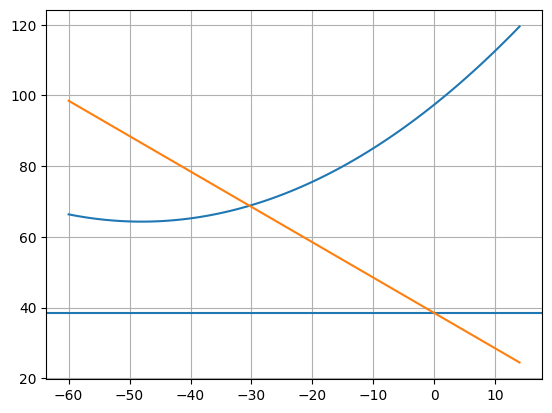

In [5]:
Dc=120
H0=38.5
L=135
H=200

fig5, ax5 = plt.subplots()

xvals_cont_1_r = xvals_cont_1-Dc/2
fit_z1_r = fit_z1+H-L
zc = -xvals_cont_1_r+H0


ax5.axhline(H0)
ax5.grid()
ax5.plot(xvals_cont_1_r, fit_z1_r, '-', label='fit')
ax5.plot(xvals_cont_1_r, zc, '-', label='fit')
ax5.plot()

Paraméteres megoldás

In [6]:
x_sym,H0_sym,H_sym,L_sym,Dc_sym,c1,c2,c3 = sp.symbols("x,H0,H,L,Dc,c1,c2,c3")

eq1 = c1*(x_sym+Dc_sym/2)**2+c2*(x_sym+Dc_sym/2)+c3+H_sym-L_sym-H0_sym+x_sym
eq1_num = eq1.subs({H0_sym:38.5,H_sym:200,Dc_sym:120,L_sym:135,
                    c1: coeffs1[0],c2: coeffs1[1],
                    c3: coeffs1[2]})


sol = sp.solve(eq1_num,x_sym)
#sol = sp.nroots(eq1_num)
print(sol)


x_dm = Dc/2+sol[1]
print(x_dm)

Dmin = abs(sol[1])
print(Dmin)

    

[-135.452314002481, -30.3192038469530]
29.6807961530470
30.3192038469530


Munkatér plot

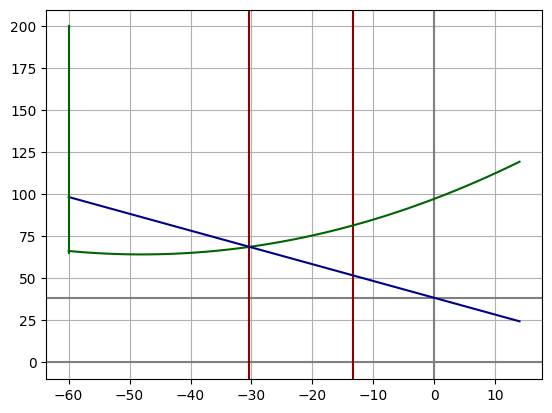

In [7]:
x_cl = 46.65 # számolni kódban szintén

fig6, ax6 = plt.subplots()

ax6.axhline(H0,color="gray")
ax6.axhline(0,color="gray")
ax6.axvline(0,color="gray")
ax6.axvline(-Dc/2+x_cl,color="darkred")
ax6.axvline(-Dc/2+x_dm,color="darkred")
ax6.grid()
ax6.plot(xvals_cont_1_r, fit_z1_r, '-', label='fit',color="darkgreen")
ax6.plot(xvals_cont_1_r, zc, '-', label='fit',color="darkblue")
ax6.plot([-Dc/2,-Dc/2],[H,H-L],color="darkgreen")
#ax6.set_aspect("equal")

